# Statistical Analysis
In this notebook we will do four statistical analysis.
1. Seasonality Test
2. Correlation and Lag Analysis
3. Time Series Decomposition.
4. Comparative Analysis

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy import stats
import warnings

# Initial setup
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

warnings.filterwarnings('ignore')

## 1. Seasonality Test
Does Malaria have a seasonal pattern or its is just random variation.

### Null hypothesis (H0)
Cases are evenly distributed across months.

### Alternate hypothesis (H1)
Cases are not evenly distributed (sesonality exists.)

In [3]:
# Load clean data
reports = pd.read_csv('../data/processed/reports_clean.csv')

# Convert data types
reports['report_date'] = pd.to_datetime(reports['report_date'])
reports['case_date'] = pd.to_datetime(reports['case_date'])

category_cols = ['age_group', 'gender']
for col in category_cols:
    reports[col] = reports[col].astype('category')

# Add a month column
reports['month'] = reports['report_date'].dt.month

#### Test for seasonality on all diseases

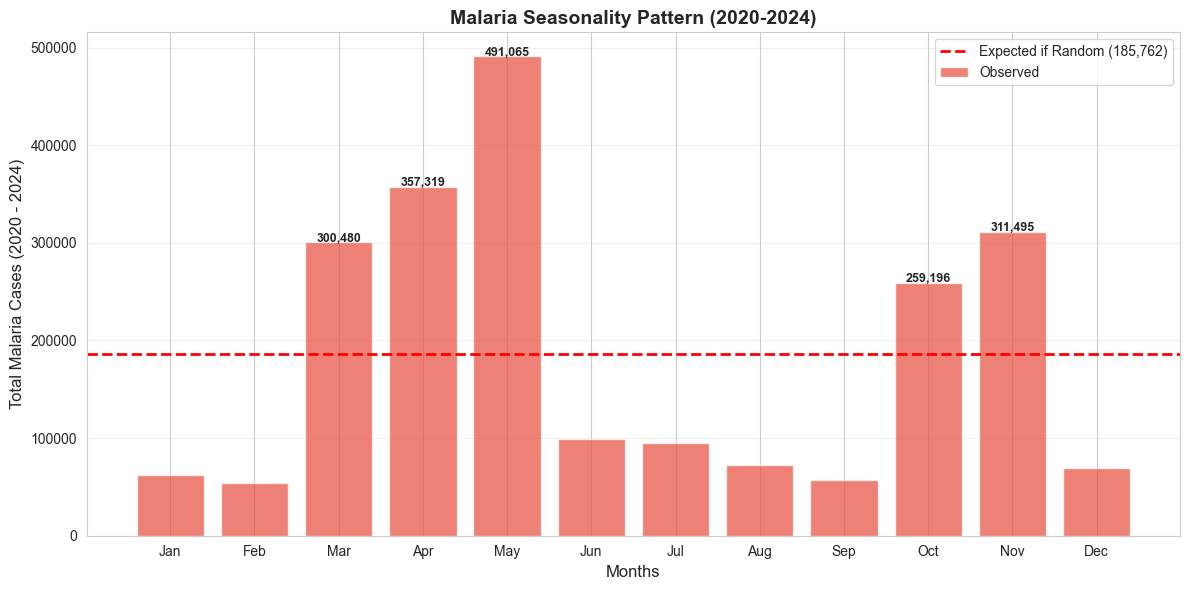

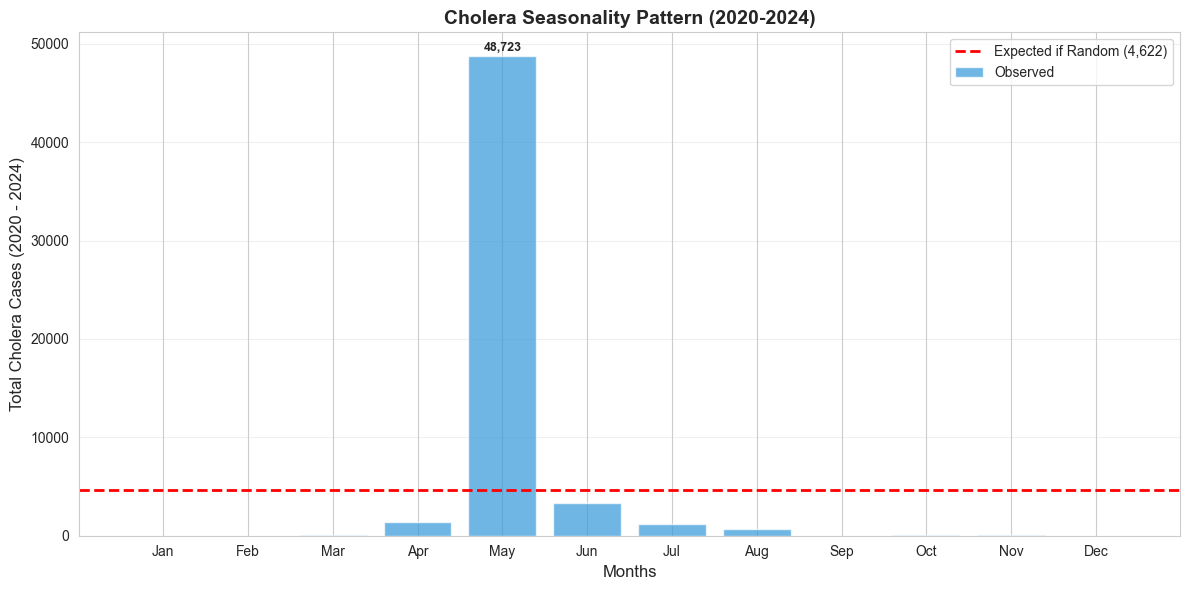

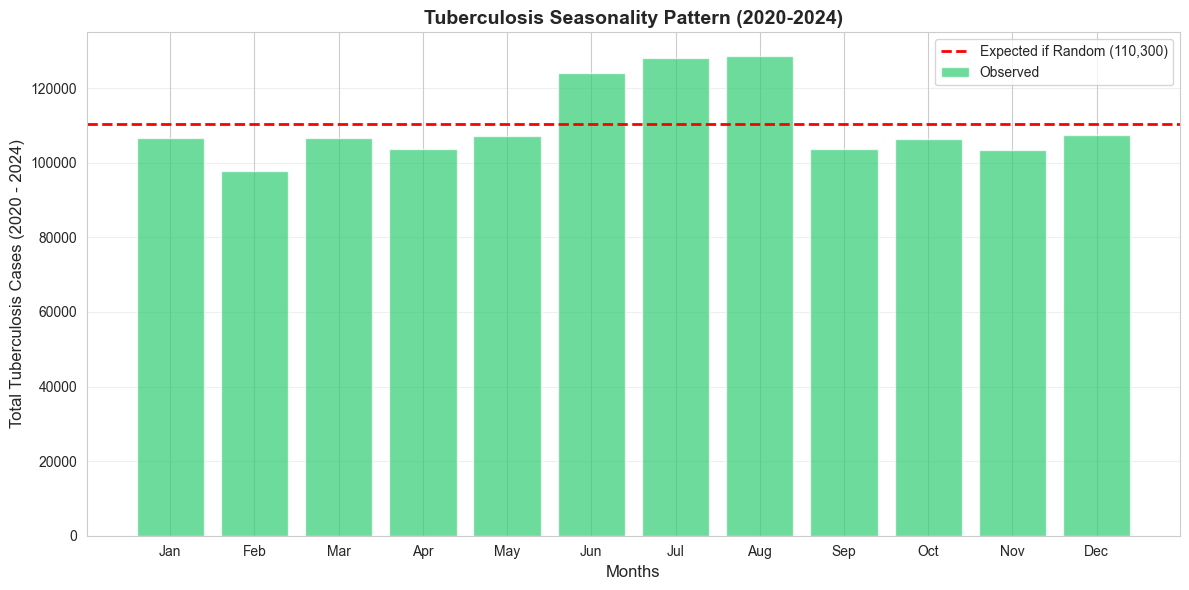

,Name of disease,Chi-Square,P-Value,Effect size,Significant,Effect
0,Malaria,1.336360e+06,0.0,0.233451,Yes,Moderate
1,Cholera,4.614004e+05,0.0,0.869666,Yes,Strong
2,Tuberculosis,1.080068e+04,0.0,0.027236,Yes,Negligible


In [52]:
diseases = ['Malaria', 'Cholera', 'Tuberculosis']
colors = ['#e74c3c', '#3498db', '#2ecc71']

results_summary = []

for i, disease in enumerate(diseases):
    disease_data = reports[reports['disease'] == disease]

    observations_per_month = disease_data.groupby('month')['new_cases'].sum()
    total = observations_per_month.sum()
    expected_observations = np.array([total / 12] * 12)
    fig, ax = plt.subplots(figsize=(12, 6))

    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    ax.bar(months, observations_per_month.values, color=colors[i], alpha=0.7, label='Observed')

    ax.axhline(y=(total / 12), color='red', linestyle='--', 
            linewidth=2, label=f'Expected if Random ({(total / 12):,.0f})')

    ax.set_xlabel('Months', fontsize=12)
    ax.set_ylabel(f'Total {disease} Cases (2020 - 2024)', fontsize=12)
    ax.set_title(f'{disease} Seasonality Pattern (2020-2024)', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    for i, (month, count) in enumerate(zip(months, observations_per_month.values)):
        if count > (total / 12) * 1.3:
            ax.text(i, count + 500, f'{count:,.0f}', ha='center', fontsize=9, fontweight='bold')


    plt.tight_layout()
    plt.savefig(f'../src/images/{disease}_monthly_trends.png')
    plt.show()

    # chi_square test
    chi2, p_val = stats.chisquare(
        f_obs = observations_per_month.values,
        f_exp = expected_observations
    )

    # Effect size
    cramers = np.sqrt(chi2 / (total * 11))

    results_summary.append({
        'Name of disease': disease,
        'Chi-Square': chi2,
        'P-Value': p_val,
        'Effect size': cramers,
        'Significant': 'Yes' if p_val < 0.05 else 'No',
        'Effect': 'Strong' if cramers > 0.3 else 'Moderate' if cramers > 0.2 else 'Weak' if cramers > 0.1 else 'Negligible'
    })

results_summary_df = pd.DataFrame(results_summary)

results_summary_df

## 2. Correlation and Lag Analysis

In this section we will perform weather-disease correlation and lag analysis. We will answers questions like:
- Does rainfall cause malaria?
- How long after rains do cases spike?
- How strong is the effect size?


In [4]:
# Load weather data
weather = pd.read_csv('../data/processed/weather_clean.csv')

# Convert dates
weather['date'] = pd.to_datetime(weather['date'])

# Filter Malaria cases
malaria = reports[reports['disease'] == 'Malaria'].copy()


In [8]:
# Aggregate to national level totals
daily_rainfall = weather.groupby('date')['rainfall_mm'].sum().reset_index()
daily_rainfall.columns = ['date', 'total_rainfall']

daily_malaria = malaria.groupby('report_date')['new_cases'].sum().reset_index()
daily_malaria.columns = ['date', 'total_cases']

# Merge
daily_data = daily_rainfall.merge(daily_malaria, on='date', how='outer')

# Fill missing cases with zero (assume there was no reports)
daily_data['total_cases'] = daily_data['total_cases'].fillna(0)
daily_data['total_rainfall'] = daily_data['total_rainfall'].fillna(0)

# Sort by date
daily_data = daily_data.sort_values('date').reset_index(drop=True)

In [46]:
# Calculate correlation

malaria_correlation = daily_data['total_rainfall'].corr(daily_data['total_cases'])
print(malaria_correlation)

# Lag correlation analysis
max_lag = 40
lag_correlations = []

for lag in range(0, max_lag + 1):
    daily_data[f'rainfall_lag{lag}'] = daily_data['total_rainfall'].shift(lag)

    corr = daily_data[f'rainfall_lag{lag}'].corr(daily_data['total_cases'])
    lag_correlations.append({
        'lag_days': lag,
        'correlation': corr
    })

lag_results = pd.DataFrame(lag_correlations)
optimal_lag = lag_results.loc[lag_results['correlation'].idxmax()]

optimal_lag_days = int(optimal_lag['lag_days'])
if optimal_lag_days < 7:
    print('Interpretation: Cases appear very quickly after rain.')
    print("This is unusual, might indicate pre-exixting infections or poor data reporting.")
elif optimal_lag_days < 14:
    print('Interpretation: Cases appear ~1-2 weeks after rain.')
    print("Inline with mosquito breeding cycle")
elif optimal_lag_days < 21:
    print('Interpretation: Cases appear ~1-2 weeks after rain.')
    print('Matches full transmission cycle + reporting delay.')
else:
    print('Interpretation: Lonf delay (3+ weeks)')



0.6729491245715516
Interpretation: Cases appear very quickly after rain.
This is unusual, might indicate pre-exixting infections or poor data reporting.


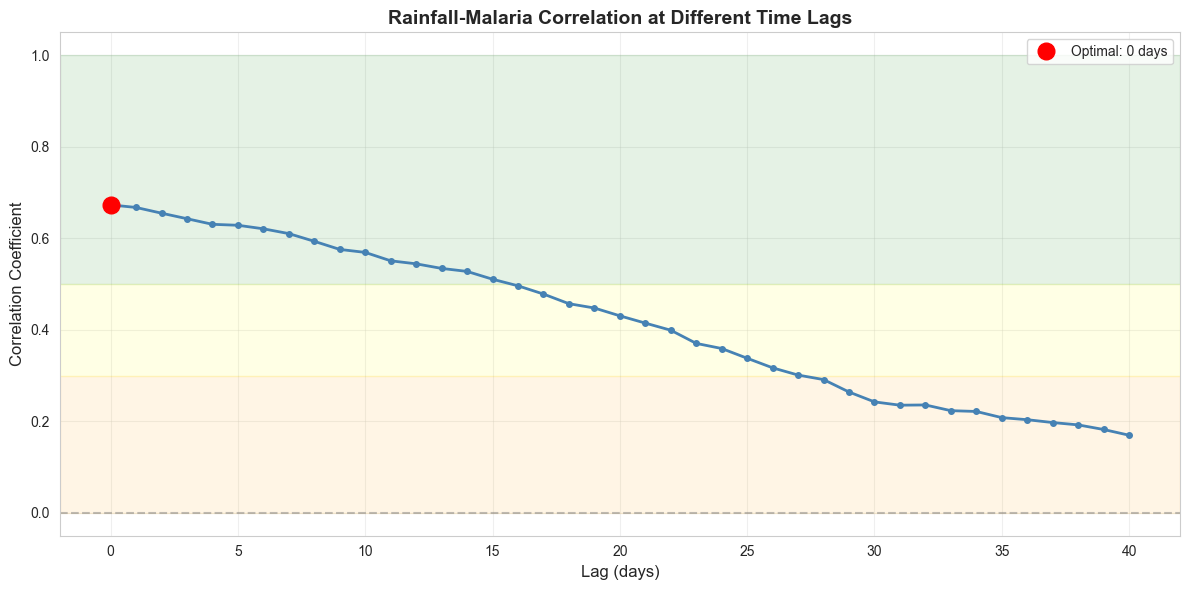

In [ ]:
# Visulaize Lag Correlations
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(lag_results['lag_days'], lag_results['correlation'], marker='o', linewidth=2, markersize=4, color='steelblue')
optimal_idx = lag_results['correlation'].idxmax()
ax.plot(optimal_lag['lag_days'], optimal_lag['correlation'], "ro", markersize=12, label=f"Optimal: {optimal_lag['lag_days']:.0f} days")
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Lag (days)', fontsize=12)
ax.set_ylabel('Correlation Coefficient', fontsize=12)
ax.set_title('Rainfall-Malaria Correlation at Different Time Lags', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax.axhspan(0.5, 1.0, alpha=0.1, color='green', label='Strong')
ax.axhspan(0.3, 0.5, alpha=0.1, color='yellow', label='Moderate')
ax.axhspan(0, 0.3, alpha=0.1, color='orange', label='Weak')

plt.tight_layout()
plt.savefig('../src/images/rainfall_malaria_lag.png')
plt.show()

In [45]:
# Statistical significant test
optimal_lag_days = int(optimal_lag['lag_days'])
rainfall_lagged = daily_data[f'rainfall_lag{optimal_lag_days}'].dropna()
cases_aligned = daily_data.loc[rainfall_lagged.index, 'total_cases']

r, p_value = stats.pearsonr(rainfall_lagged, cases_aligned)

print(r, p_value.round(4))


0.6729491245715516 0.0


In [47]:
# Scatter plot

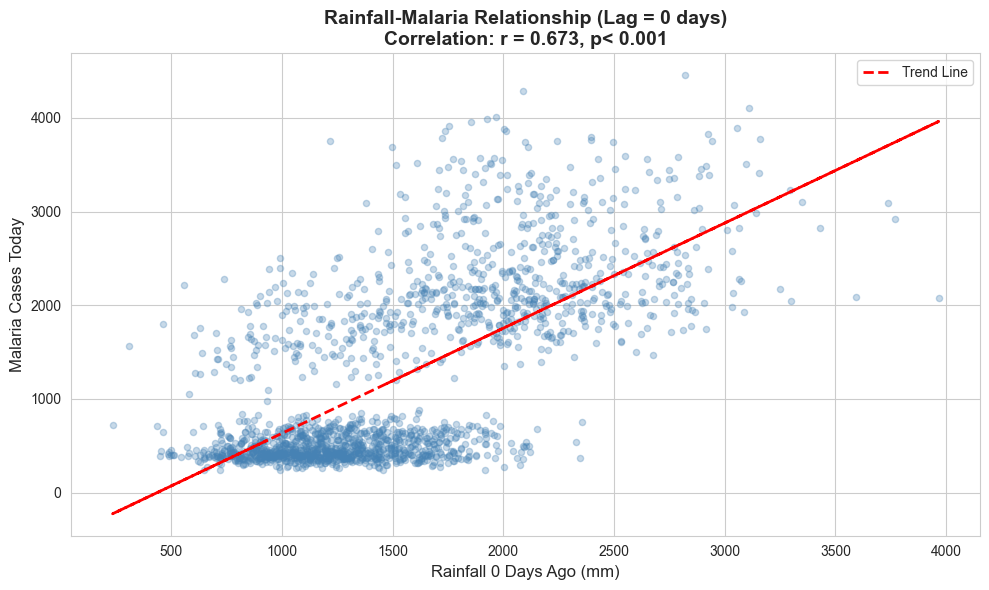

In [56]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(rainfall_lagged, cases_aligned, alpha=0.3, s=20, color='steelblue')
z = np.polyfit(rainfall_lagged, cases_aligned, 1)
p = np.poly1d(z)
ax.plot(rainfall_lagged, p(rainfall_lagged), "r--", linewidth=2, label='Trend Line')

ax.set_xlabel(f"Rainfall {optimal_lag_days} Days Ago (mm)", fontsize=12)
ax.set_ylabel('Malaria Cases Today', fontsize=12)
ax.set_title(f'Rainfall-Malaria Relationship (Lag = {optimal_lag_days} days)\n'
             f"Correlation: r = {r:.3f}, p< 0.001",
             fontsize=14, fontweight='bold')

ax.legend()

plt.tight_layout()
plt.savefig('../src/images/rainfall_lag0.png')
plt.show()